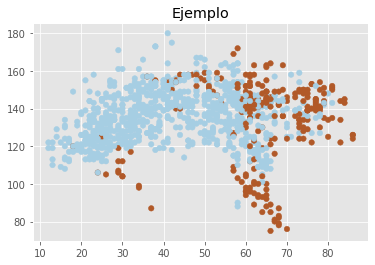

In [ ]:
##############
# SVM LINEAL #
##############

# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

# Preprocesado y modelado
# ==============================================================================
from sklearn.svm import SVC
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

file = '/content/data/ASI_casoPractico.csv'
data = pd.read_csv(file, sep = ';')
data = data.drop(["ID","b","e","DR"], axis = 1)

# Solo se cogen dos variables a modo de ejemplo: Mean y Variance
vars = ["ASTV","Mean"]
X = data[vars]
y = data.loc[:, data.columns == "Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.50, random_state = 0)

fig, ax = plt.subplots(figsize=(6,4))
plt.scatter(X_train.ASTV, X_train.Mean, c = y_train.Target, s=30, cmap=plt.cm.Paired)
ax.set_title("EStado de salud fetal");

In [ ]:
# Creación del modelo SVM lineal
# ==============================================================================
modelo = SVC(C = 10, kernel = 'linear', random_state=123)
modelo.fit(X_train, y_train)

SVC(C=10, kernel='linear', random_state=123)

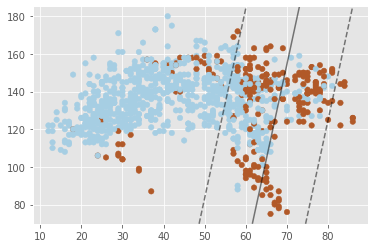

In [ ]:
# Creación del modelo SVM lineal
# ==============================================================================
plt.scatter(X_train.ASTV, X_train.Mean, c = y_train.Target, s=30, cmap=plt.cm.Paired)

# Funcion de decision
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Grid para evaluar el modelo
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = modelo.decision_function(xy).reshape(XX.shape)

# Plano de decision
ax.contour(
    XX, YY, Z, colors="k", levels=[-1, 0, 1], alpha=0.5, linestyles=["--", "-", "--"]
)
# plot support vectors
plt.show()

In [ ]:
# Predicciones test
# ==============================================================================
predicciones_train = modelo.predict(X_train)
predicciones_test = modelo.predict(X_test)

In [ ]:
# Accuracy de test del modelo 
# ==============================================================================
accuracy = accuracy_score(y_true = y_train,y_pred = predicciones_train,normalize = True)
print(f"El accuracy de training es: {100*accuracy}%")

accuracy = accuracy_score(y_true = y_test,y_pred = predicciones_test,normalize = True)
print(f"El accuracy de test es: {100*accuracy}%")

# Matriz de confusión de las predicciones de test
# ==============================================================================
confusion_matrix = pd.crosstab(
    y_test.Target.ravel(),
    predicciones_test,
    rownames=['Real'],
    colnames=['Predicción']
)
print(confusion_matrix)

El accuracy de training es: 83.34901222953904%
El accuracy de test es: 83.16086547507055%
Predicción    0   1
Real               
0           799  30
1           149  85
